# Effect of Single Amino Acid Mutations

This notebook uses a protein language model (PLM) from the huggingface repository called [ESM++](https://huggingface.co/Synthyra/ESMplusplus_large). The PLM works as a maked LLM model. The model uses hundreds of millions of protein sequences and learns to use amino acid context to predict hidden amino acids (e.g. if the training data sequence is MEGT, the model tries to learn that G goes in ME_T).Essentially, it tries to learn the language of protein sequences. Using these models, we can seek to predict the effect of single point mutations in an amino acid sequence, similar to a deep mutational scan. This code was based on ESM tutorials developed for CompBio Asia 2026

In [1]:
#@title Install Neccessary Packages

!pip install transformers
!pip install biopython
!pip install matplotlib
!pip install scikit-learn
!pip install pandas
!pip install torch

from transformers import AutoTokenizer, AutoModelForMaskedLM
from Bio import SeqIO
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.5 MB/s eta 0:00:00


Note that it may be useful to switch to a GPU for faster analysis. Clock on Runtime -> Change runtime type -> T4 GPU.

In [2]:
#@title Load Model
size = "large" #@param ["small", "large"]
model = AutoModelForMaskedLM.from_pretrained(f"Synthyra/ESMplusplus_{size}", trust_remote_code=True)
tokenizer = model.tokenizer

# use gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# move model to gpu
model.to(device)

# because we're not training
model.eval()

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

modeling_fastplms.py:   0%|          | 0.00/7.83k [00:00<?, ?B/s]

fastplms_bundle.py:   0%|          | 0.00/154k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/Synthyra/ESMplusplus_large:
- fastplms_bundle.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] A new version of the following files was downloaded from https://huggingface.co/Synthyra/ESMplusplus_large:
- modeling_fastplms.py
- fastplms_bundle.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.30GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/368 [00:00<?, ?it/s]

ESMplusplusForMaskedLM(
  (_sae_models): ModuleDict()
  (embed): Embedding(64, 1152)
  (transformer): TransformerStack(
    (blocks): ModuleList(
      (0-35): 36 x UnifiedTransformerBlock(
        (attn): MultiHeadAttention(
          (layernorm_qkv): Sequential(
            (0): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=1152, out_features=3456, bias=False)
          )
          (out_proj): Linear(in_features=1152, out_features=1152, bias=False)
          (q_ln): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
          (k_ln): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
          (rotary): RotaryEmbedding()
        )
        (ffn): Sequential(
          (0): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
          (1): Linear(in_features=1152, out_features=6144, bias=False)
          (2): SwiGLU()
          (3): Linear(in_features=3072, out_features=1152, bias=False)
        )
        (dropout): Dropout(p=0.0,

## Running mutation effection analysis on hemaglobin beta

Here, we will predict mutation effects on human RHO, with the sequence being obtained from UniProt Entry [P08100
](https://www.uniprot.org/uniprotkb/P08100/entry).

To use the model, we mask the amino acid at each position, and then run the model to obtain a probability distribution for each single-point mutation to each AA.

In [3]:
# @title Input Sequence
protein_sequence = 'MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH' #@param {type:"string"}
print("Length of RHO:", len(protein_sequence))

# 2. Tokenize and run model once
inputs = tokenizer(protein_sequence, return_tensors="pt").to(device)
input_ids = inputs["input_ids"][0]
mask_token_id = tokenizer.mask_token_id

seq_len = input_ids.shape[0]
num_aa = seq_len - 2  # exclude [CLS] and [EOS]

vocab_size = model.config.vocab_size

all_logits = torch.zeros(num_aa, vocab_size).to(device)
all_logits_softmax = torch.zeros(num_aa, vocab_size).to(device)

with torch.no_grad():
  for i in range(1, seq_len - 1):
    if i % 20 == 0:
      print(f"Progress: {i}/{seq_len - 2}")
    masked_input_ids = input_ids.clone()
    masked_input_ids[i] = mask_token_id
    masked_inputs = {"input_ids": masked_input_ids.unsqueeze(0), "attention_mask": inputs["attention_mask"]}
    output = model(**masked_inputs)
    logits = output.logits[0, i, :]
    log_probs = logits.log_softmax(dim=-1)
    all_logits[i - 1] = logits
    all_logits_softmax[i - 1] = log_probs

logits = all_logits
log_probs = all_logits_softmax

# Helper: map residue index (1-based) -> token position in input_ids
def residue_index_to_token_pos(target_res_idx, input_ids, tokenizer):
    residue_index = 0
    for token_pos in range(input_ids.size(0)):
        token_id = input_ids[token_pos].item()
        token_str = tokenizer.convert_ids_to_tokens(token_id)
        if token_str in tokenizer.all_special_tokens:
            continue
        residue_index += 1
        if residue_index == target_res_idx:
            return token_pos
    return None

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Length of RHO: 147
Progress: 20/147
Progress: 40/147
Progress: 60/147
Progress: 80/147
Progress: 100/147
Progress: 120/147
Progress: 140/147


Now, we analyze the probability distributions. First, we produce a heatmap displaying the what the model thinks the probability of each residue being each AA is, given its sequence context.

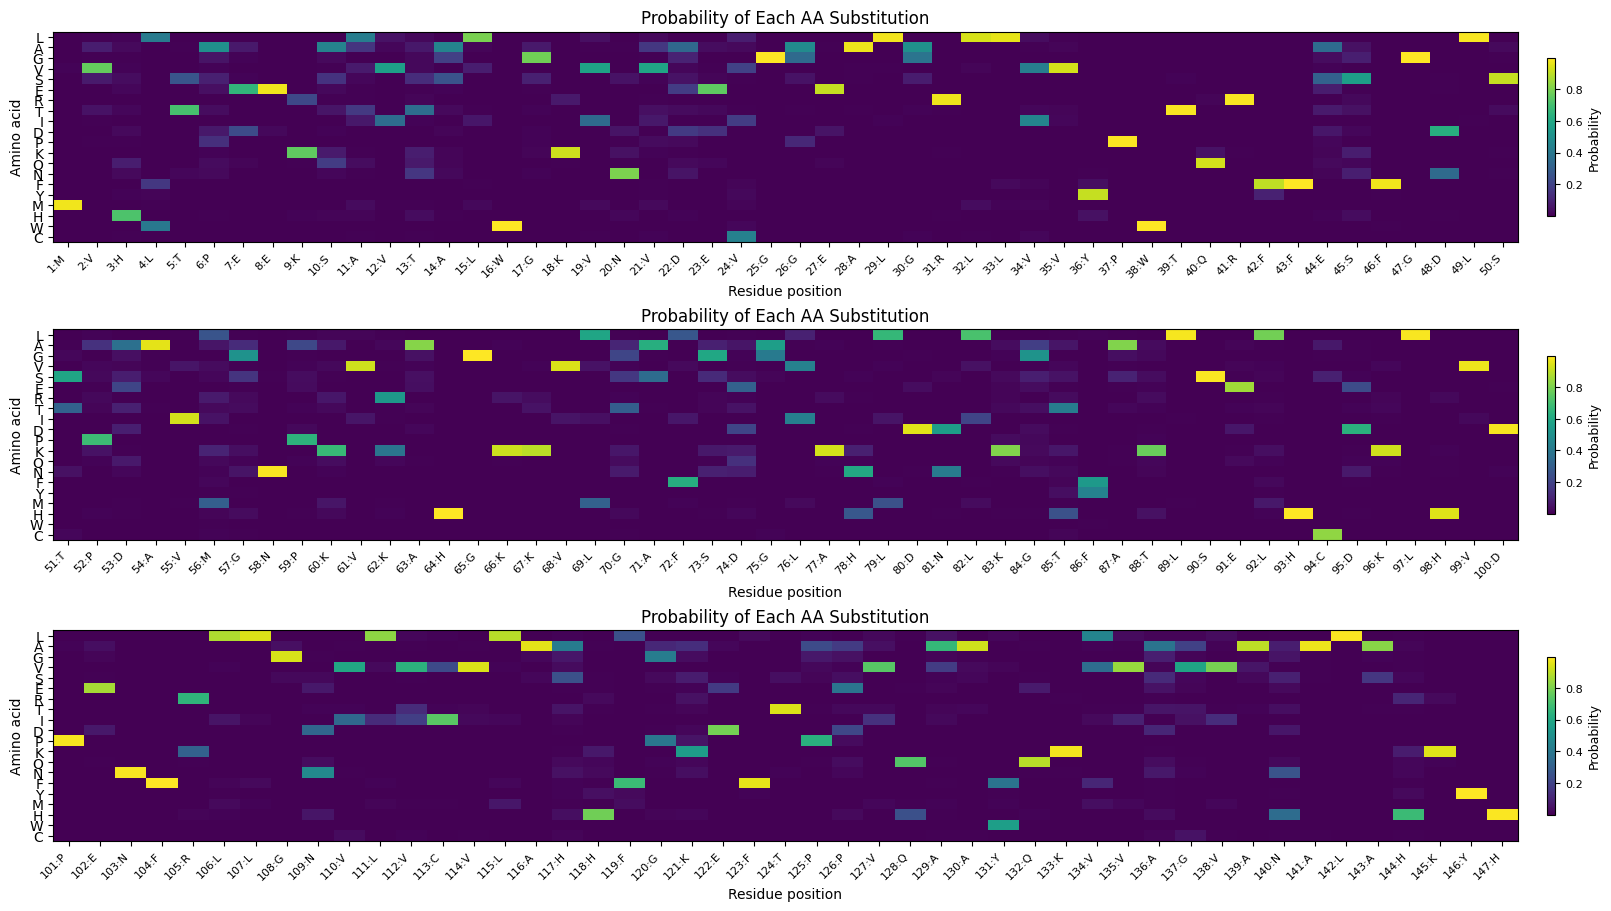

In [4]:
# @title Plot amino acid probablities
amino_acids = list("LAGVSERTIDPKQNFYMHWC")

probs = log_probs.exp()

start_residue = 1 # @param {type:"integer"}
end_residue = 147 # @param {type:"integer"}

residue_positions = list(range(start_residue, end_residue + 1))
residue_positions2 = [pos - 1 for pos in residue_positions]
x_labels = [f"{pos}:{protein_sequence[pos-1]}" for pos in residue_positions]
aa_token_ids = tokenizer.convert_tokens_to_ids(amino_acids)

heat = probs[residue_positions2][:, aa_token_ids].T
heat = heat.detach().cpu().numpy()

residues_per_row = 50

n_residues = heat.shape[1]
n_rows = math.ceil(n_residues / residues_per_row)

fig, axes = plt.subplots(
    n_rows,
    1,
    figsize=(16, 3 * n_rows),
    constrained_layout=True
)

if n_rows == 1:
    axes = [axes]

for row, ax in enumerate(axes):
    start = row * residues_per_row
    end = min(start + residues_per_row, n_residues)

    heat_slice = heat[:, start:end]
    labels_slice = x_labels[start:end]

    im = ax.imshow(heat_slice, aspect="auto", cmap="viridis")

    ax.set_xticks(np.arange(len(labels_slice)))
    ax.set_xticklabels(labels_slice, rotation=45, ha="right", fontsize=8)

    ax.set_yticks(np.arange(len(amino_acids)))
    ax.set_yticklabels(amino_acids)

    ax.set_xlabel("Residue position")
    ax.set_ylabel("Amino acid")
    ax.set_title(f"Probability of Each AA Substitution")
    # Do "EC Loop 2 (Residues {start+1}–{end})" Later

    # Small individual colorbar for this row
    cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label("Probability", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

plt.show()

Next, we produce a heatmap of the ΔlogP score for each variant This score is calculated $$\log P_{aa} - \log P_{WT}$$, where $P_{aa}$ is the probability of the mutant AA and $P_{WT}$ is the probability of the wildtype AA. This gives a relative log likelihood, where a value greater than 0 suggests it is statistically favoured in the PLM, while a value less than 0 suggests the wildtype is statistically favoured.

Biologically, scores significantly less than 0 indicate deleterious/pathogenic mutations. Scores around 0 indicate benign/neutral mutations and scores above 0 can be benign, but can also be beneficial or function-changing mutants.

---




ΔlogP (mut - WT) matrix:


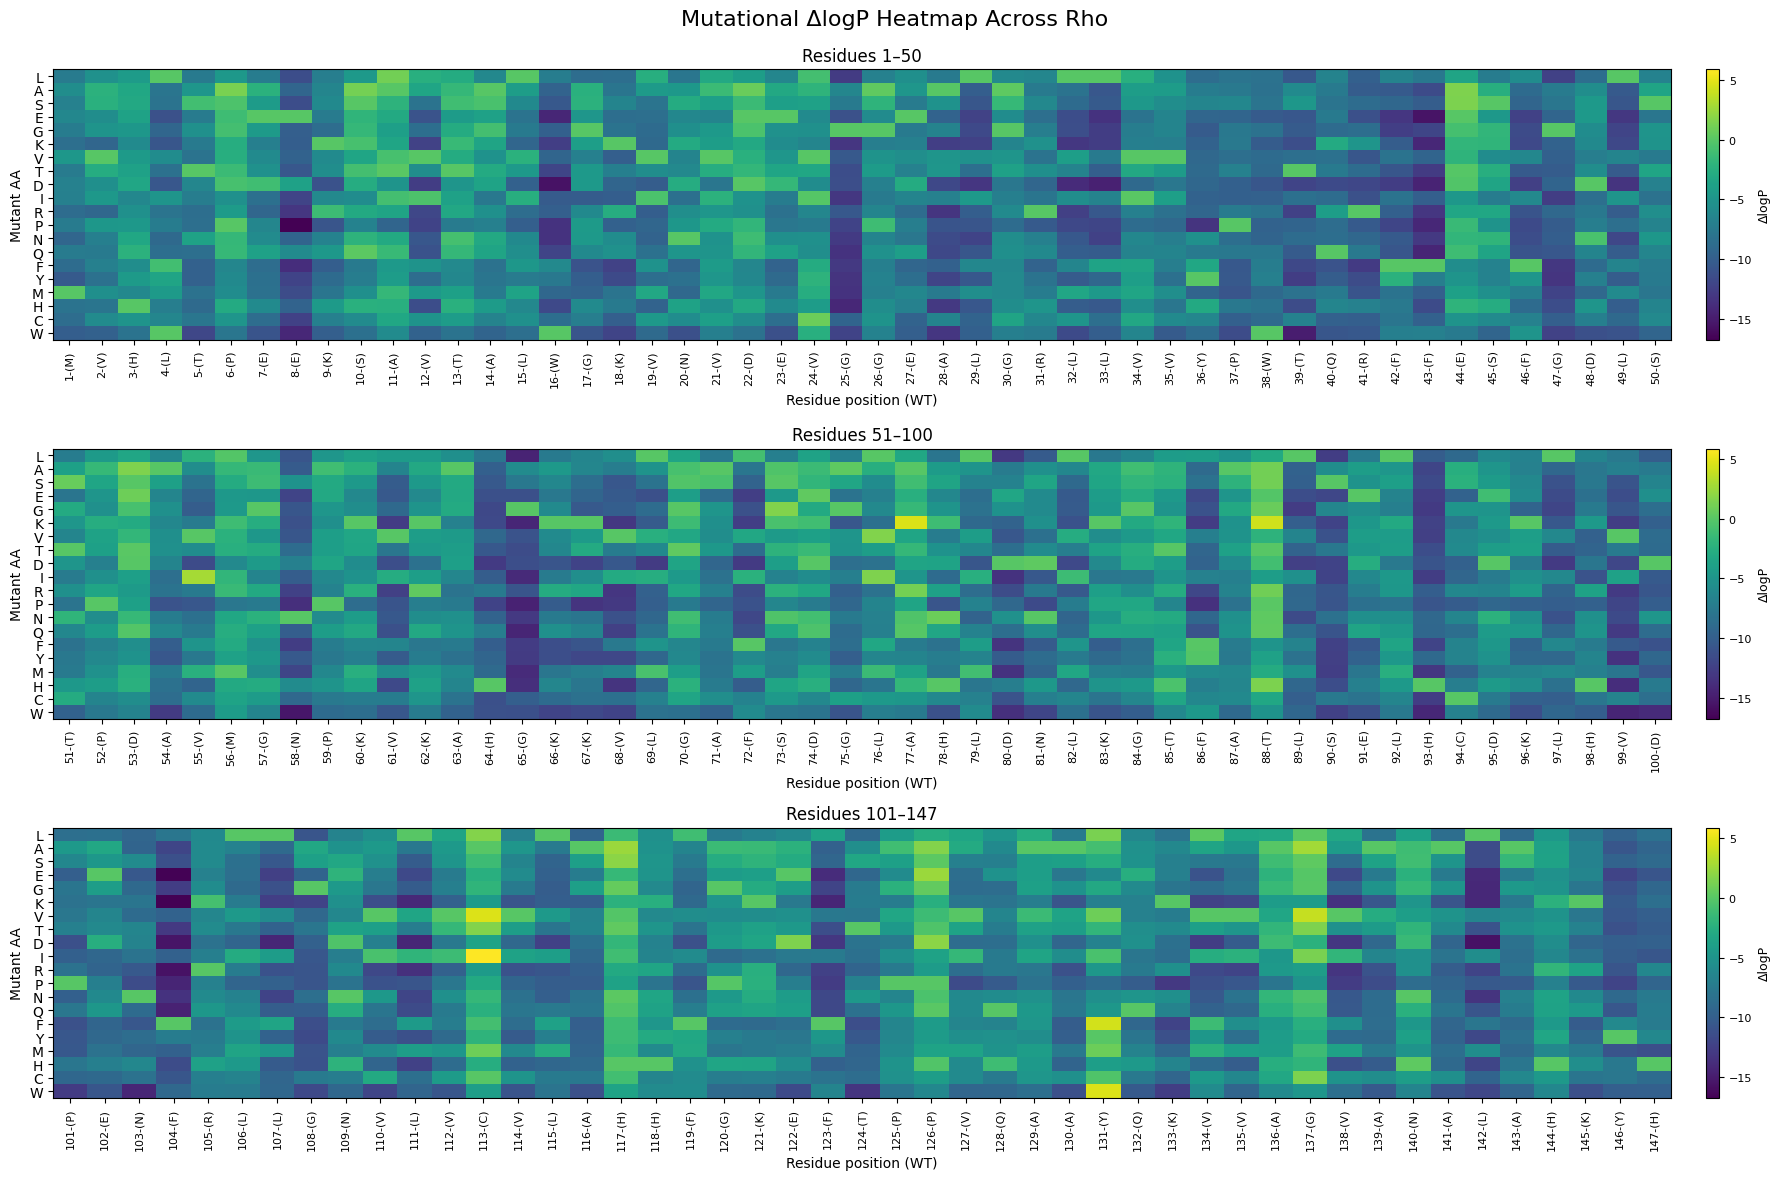

In [5]:
# @title Heatmap of ΔlogP Scores
amino_acids = list("WCHMYFQNPRIDTVKGESAL")
n_aa = len(amino_acids)

start_residue = 1 # @param {type:"integer"}
end_residue = 147 # @param {type:"integer"}

positions = list(range(start_residue, end_residue + 1))
n_pos = len(positions)

# Matrix of ΔlogP: rows = AA, cols = positions
delta_logP_matrix = np.zeros((n_aa, n_pos))

# Track WT amino acids at each position
wt_aas = []

for j, res_idx in enumerate(positions):
    token_pos = residue_index_to_token_pos(res_idx, input_ids, tokenizer)
    assert token_pos is not None, f"Could not map residue {res_idx} to token position."

    pos_log_probs = log_probs[token_pos - 1]  # (vocab_size,)

    wt_aa = protein_sequence[res_idx - 1]  # sequence string is 0-based
    wt_aas.append(wt_aa)

    wt_id = tokenizer.convert_tokens_to_ids(wt_aa)
    logP_WT = pos_log_probs[wt_id].item()

    for i, aa in enumerate(amino_acids):
        aa_id = tokenizer.convert_tokens_to_ids(aa)
        logP_aa = pos_log_probs[aa_id].item()
        delta_logP_matrix[i, j] = logP_aa - logP_WT

# 7. Wrap into a DataFrame
df_heat = pd.DataFrame(
    delta_logP_matrix,
    index=amino_acids,
    columns=[f"{pos}({wt})" for pos, wt in zip(positions, wt_aas)]
)

print("\nΔlogP (mut - WT) matrix:")
#print(df_heat.round(3).to_string())

# 8. Plot heatmap

# Number of residue positions per heatmap
chunk_size = 50

# Number of heatmaps needed
n_chunks = (n_pos + chunk_size - 1) // chunk_size

fig, axes = plt.subplots(n_chunks, 1, figsize=(18, 4 * n_chunks))

# If there's only one subplot, make axes iterable
if n_chunks == 1:
    axes = np.array([axes])

# Keep the same color scale across all heatmaps
vmin = np.min(delta_logP_matrix)
vmax = np.max(delta_logP_matrix)

for i in range(n_chunks):
    start = i * chunk_size
    end = min(start + chunk_size, n_pos)

    ax = axes[i]

    img = ax.imshow(
        delta_logP_matrix[:, start:end],
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xticks(np.arange(end - start))
    ax.set_xticklabels(
        [f"{positions[j]}-({wt_aas[j]})" for j in range(start, end)],
        rotation=90,
        fontsize=8
    )

    ax.set_yticks(np.arange(n_aa))
    ax.set_yticklabels(amino_acids, fontsize=10)

    ax.set_xlabel("Residue position (WT)")
    ax.set_ylabel("Mutant AA")
    ax.set_title(f"Residues {positions[start]}–{positions[end-1]}")

    # Add a colorbar for this subplot only
    cbar = fig.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("ΔlogP", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

fig.suptitle("Mutational ΔlogP Heatmap Across Rho", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()